In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
import warnings

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11

In [2]:
df = pd.read_csv("../data/processed/tickets_clean.csv")
df_en = df[df["language"] == "en"].copy().reset_index(drop=True)

print("영어 티켓 수:", len(df_en))
print(df_en["type"].value_counts())

영어 티켓 수: 16335
type
Incident    6571
Request     4665
Problem     3394
Change      1705
Name: count, dtype: int64


In [3]:
# 피처
df_en["text"] = df_en["subject"].fillna("") + " " + df_en["body"].fillna("")
df_en["text"] = df_en["text"].str.lower().str.strip()

X = df_en["text"]
y = df_en["type"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("train:", len(X_train), "/ test:", len(X_test))

train: 13068 / test: 3267


In [4]:
# TF-IDF 벡터화

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=3,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print("TF-IDF shape (train):", X_train_tfidf.shape)

TF-IDF shape (train): (13068, 5000)


In [5]:
# Logistic Regression

model = LogisticRegression(
    max_iter=1000,
    C=1.0,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

print("=== Accuracy ===")
print(f"{accuracy_score(y_test, y_pred):.4f}")
print()
print("=== Classification Report ===")
print(classification_report(y_test, y_pred))

=== Accuracy ===
0.8264

=== Classification Report ===
              precision    recall  f1-score   support

      Change       0.97      0.99      0.98       341
    Incident       0.83      0.72      0.77      1314
     Problem       0.57      0.72      0.64       679
     Request       0.99      0.99      0.99       933

    accuracy                           0.83      3267
   macro avg       0.84      0.86      0.85      3267
weighted avg       0.84      0.83      0.83      3267



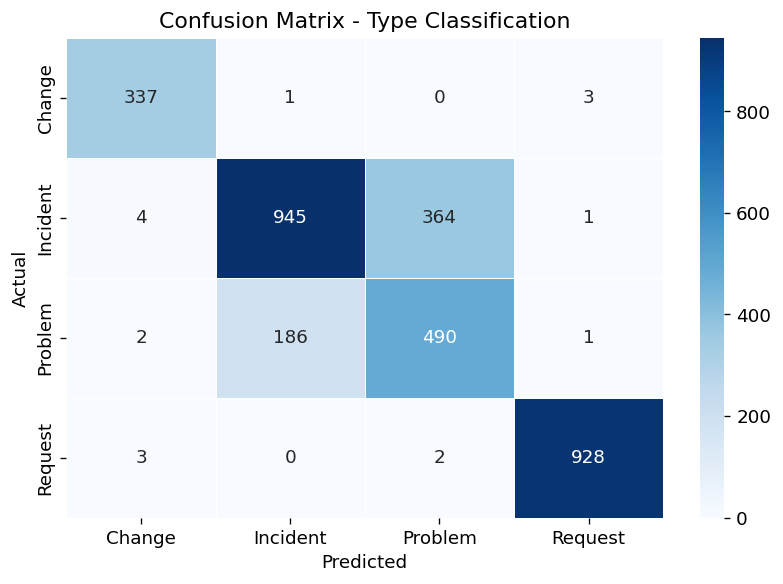

In [7]:
# 혼동행렬

labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt=",",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    linewidths=0.5,
    ax=ax
)
ax.set_title("Confusion Matrix - Type Classification")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig("../outputs/figures/04_confusion_matrix.png")
plt.show()

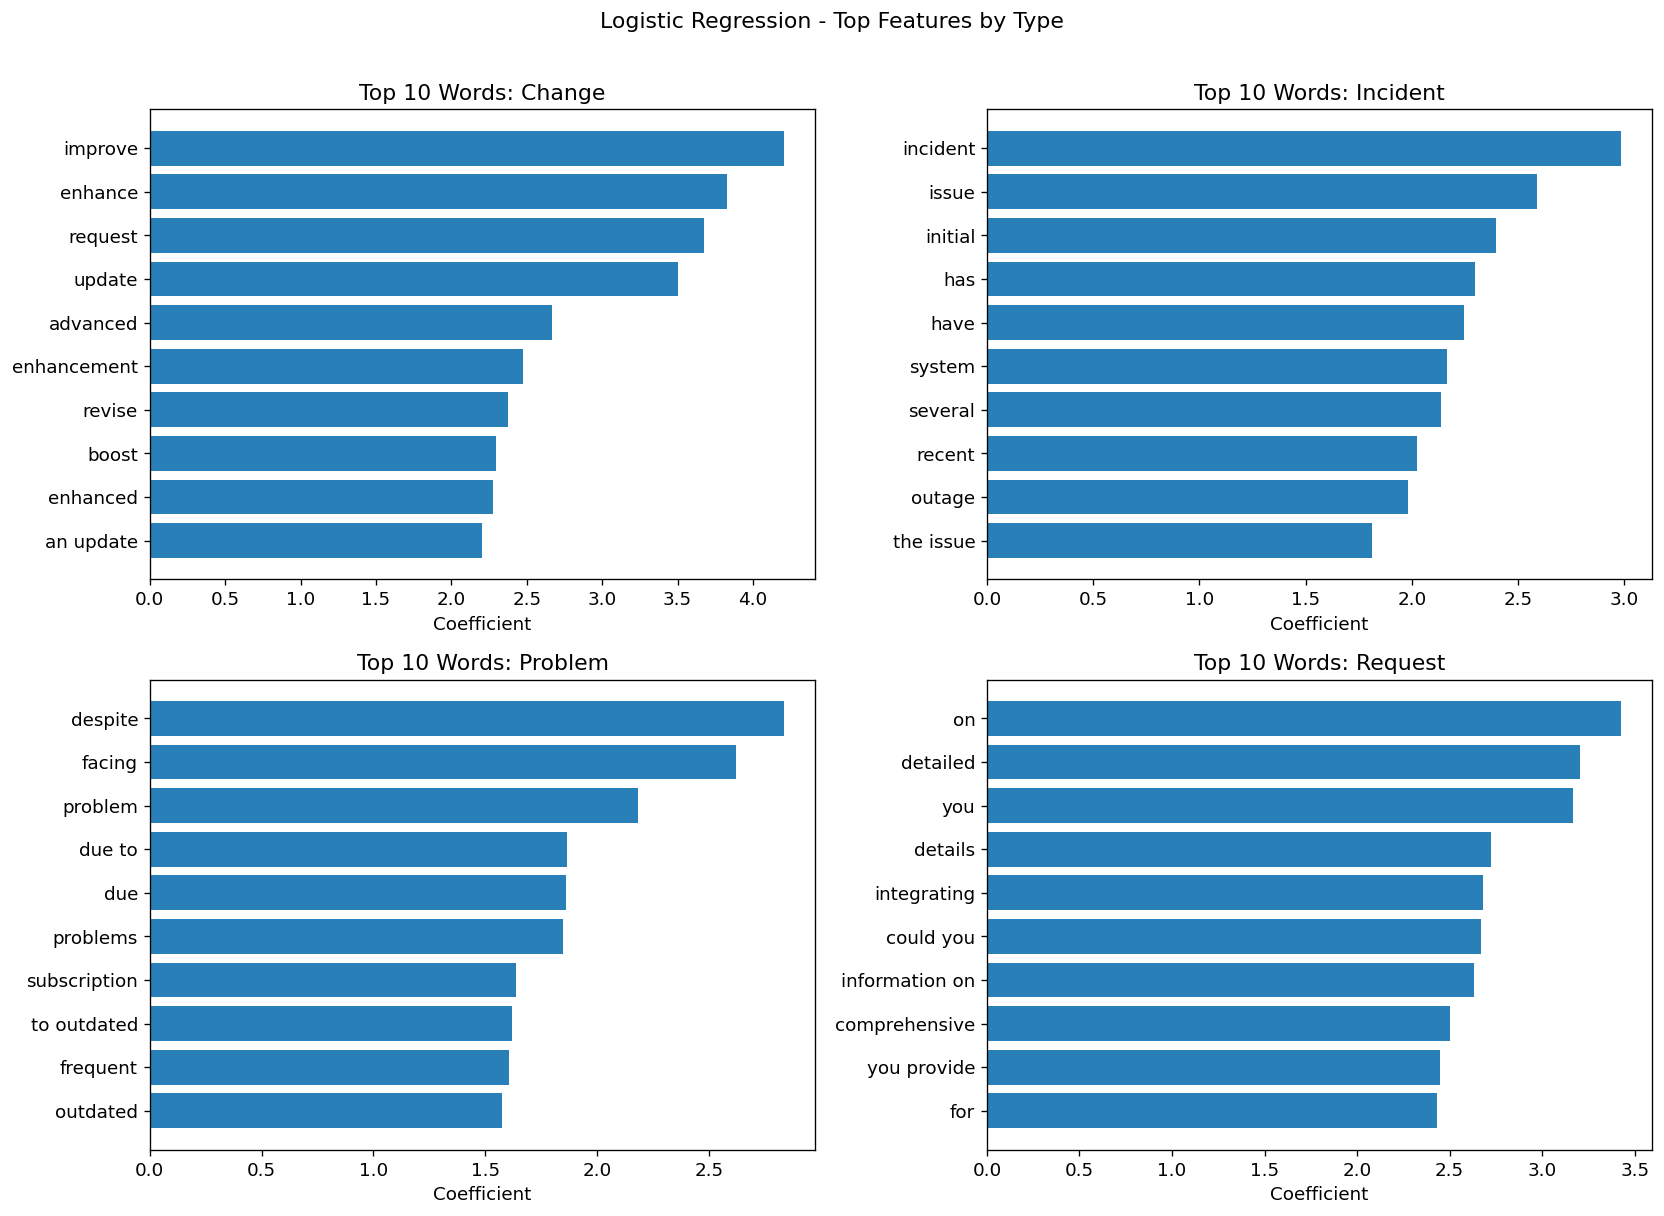

In [8]:
# 피처 중요도 - 각 클래스별 Top 10 단어

feature_names = tfidf.get_feature_names_out()
classes       = model.classes_

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, cls in enumerate(classes):
    coef = model.coef_[idx]
    top_idx = np.argsort(coef)[-10:][::-1]
    top_words  = [feature_names[i] for i in top_idx]
    top_scores = [coef[i] for i in top_idx]

    axes[idx].barh(top_words[::-1], top_scores[::-1], color="#2980b9")
    axes[idx].set_title(f"Top 10 Words: {cls}")
    axes[idx].set_xlabel("Coefficient")

plt.suptitle("Logistic Regression - Top Features by Type", y=1.01)
plt.tight_layout()
plt.savefig("../outputs/figures/04_feature_importance.png")
plt.show()

In [11]:

# 오분류 분석

results = X_test.to_frame().copy()
results["actual"]    = y_test.values
results["predicted"] = y_pred

wrong = results[results["actual"] != results["predicted"]].copy()
wrong["text_preview"] = wrong["text"].str[:120]

print(f"오분류 건수: {len(wrong)} / {len(y_test)} ({len(wrong)/len(y_test)*100:.1f}%)")
print()
print("오분류 actual vs predicted 분포")
print(pd.crosstab(wrong["actual"], wrong["predicted"]))

오분류 건수: 567 / 3267 (17.4%)

오분류 actual vs predicted 분포
predicted  Change  Incident  Problem  Request
actual                                       
Change          0         1        0        3
Incident        4         0      364        1
Problem         2       186        0        1
Request         3         0        2        0
